INICIAMOSS

In [ ]:
# Imports generales
import pandas as pd
import io
import numpy as np
import time

import seaborn as sns                        # libreria para graficos
import matplotlib.pyplot as plt              # libreria para graficos



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
##df_informe062024 = pd.read_csv('/content/drive/MyDrive/TFM/dataset/Informe062024.xlsx', sep=",")
##display(df_informe062024.head())

df_informe062024 = pd.read_excel('/content/drive/MyDrive/TFM/dataset/Informe062024.xlsx')
display(df_informe062024.head())


,Año,Mes,Encargo,Contrato,Grupo Remedy,Ref. Externa,Encargos Repetidos,Agrupación,Tipo Agrupación,Título,...,Tipo Solución,Solución Usuario,Solución Técnica,Entorno,Nº Reclamaciones,Nº Reaperturas,F. Cancelación,Tarifa,Coste,Renovación
0,2024,MAYO,WO0000000341216,ECON/XXXX,RRHH,INC000002081538,3,NaN,NaN,Contrato con horario incorrecto,...,Con éxito,Ya está solucionado,Ya está solucionado,PROD,0,1,NaT,NaN,"0,00",No
1,2024,MAYO,WO0000000341075,ECON/XXXX,RRHH,INC000002093851,2,NaN,NaN,SSRE: No puedo realizar un trámite,...,Con éxito,Se realizan los cambios solicitados en la afil...,Se realizan los cambios en departamental e ins...,PROD,0,0,NaT,NaN,"0,00",No
2,2024,MAYO,WO0000000340865,ECON/XXXX,RRHH,INC000002081538,3,NaN,NaN,Contrato con horario incorrecto,...,Con éxito,Se ha modificado el horario,Se ha modificado el horario,PROD,0,1,NaT,NaN,"0,00",No
3,2024,MAYO,WO0000000340857,ECON/XXXX,RRHH,INC000002095748,2,NaN,NaN,SIRI: No puedo realizar un trámite,...,Con éxito,Se ajustan las situaciones de nómina tanto en ...,Se ajustan situaciones de nómina.,PROD,0,0,NaT,NaN,"0,00",No
4,2024,MAYO,WO0000000340695,ECON/XXXX,RRHH,INC000002086624,5,NaN,NaN,Cambio contrato profesora de religión ERIKA YA...,...,Con éxito,Se actualizan datos,Se actualizan datos,PROD,0,1,NaT,NaN,"0,00",No


In [ ]:
#columnas del dataset
df_informe062024.columns

Index(['Año', 'Mes', 'Encargo', 'Contrato', 'Grupo Remedy', 'Ref. Externa',
       'Encargos Repetidos', 'Agrupación', 'Tipo Agrupación', 'Título',
       'Descripción del Encargo', 'Tipo Objeto', 'Objeto Encargo', 'Prioridad',
       'Login Proveedor', 'Login Cambio', 'Estado', 'Motivo del Estado',
       'F. Inicio Estado 1', 'F. Inicio Estado 2', 'F. Inicio Estado',
       'F. Registro', 'F. Asignación', 'Tiempo de Resolución (h)',
       'F. Objetivo', 'Tiempo de Resolución Vigente (h)', 'Módulo Técnico',
       'F. Requerida Valoración', 'F. Requerida Entrega',
       'F. Entrega Valoración', 'F. Compromiso', 'F. Comienzo Ejecución',
       'F. Primera Entrega', 'F. Entrega', 'F. Resolución ICM',
       'F. Aceptación', 'F. Pte. Paso a Producción', 'F. Certificación',
       'F. Aceptación Valoración', 'F. Cierre', 'Aplicación',
       'Módulo Funcional', 'Relevancia',
       'Servicio de Localización e Intervención',
       '¿Encargo excluido de todos los ANS?', 'ANS excluidos de

In [ ]:
# Total filas/columnas que componen el dataset.
df_informe062024.shape

(637, 75)

In [ ]:
df_informe062024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637 entries, 0 to 636
Data columns (total 75 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Año                                      637 non-null    int64         
 1   Mes                                      637 non-null    object        
 2   Encargo                                  637 non-null    object        
 3   Contrato                                 637 non-null    object        
 4   Grupo Remedy                             637 non-null    object        
 5   Ref. Externa                             631 non-null    object        
 6   Encargos Repetidos                       637 non-null    int64         
 7   Agrupación                               0 non-null      float64       
 8   Tipo Agrupación                          0 non-null      float64       
 9   Título                                   63

In [ ]:
# Se obtienen las cantidades de valores nulos por columna

pd.options.display.max_columns = 0
pd.options.display.max_rows = 0

nulos_x_columna = df_informe062024.isna().sum()
print(f"Cantidad de filas que tienen valores nulos por atributo:\n{nulos_x_columna}")

Cantidad de filas que tienen valores nulos por atributo:
Año                          0
Mes                          0
Encargo                      0
Contrato                     0
Grupo Remedy                 0
Ref. Externa                 6
Encargos Repetidos           0
Agrupación                 637
Tipo Agrupación            637
Título                       0
Descripción del Encargo      0
Tipo Objeto                  0
                          ... 
Clave Centro                55
Criticidad Aplicación      633
Tipo Solución              495
Solución Usuario             0
Solución Técnica             5
Entorno                      1
Nº Reclamaciones             0
Nº Reaperturas               0
F. Cancelación             629
Tarifa                     637
Coste                        0
Renovación                  20
Length: 75, dtype: int64


In [ ]:
# EJEMPLO: Contar valores perdidos
df_informe062024.isnull().sum()

,0
Año,0
Mes,0
Encargo,0
Contrato,0
Grupo Remedy,0
...,...
Nº Reaperturas,0
F. Cancelación,629
Tarifa,637
Coste,0


In [ ]:
for column in df_informe062024.columns:
    if df_informe062024[column].isnull().sum()!=0:
        print(df_informe062024[column].describe(),"\n\n")

count                 631
unique                576
top       INC000002080405
freq                    4
Name: Ref. Externa, dtype: object 


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Agrupación, dtype: float64 


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Tipo Agrupación, dtype: float64 


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: F. Inicio Estado 2, dtype: float64 


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: F. Inicio Estado, dtype: float64 


count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Módulo Técnico, dtype: float64 


count                      2
mean     2024-02-05 12:00:00
min      2023-10-31 00:00:00
25%      2023-12-18 18:00:00
50%      2024-02-05 

In [ ]:
# Para la librería dtale en colab
!pip install Dtale
import dtale
import dtale.app as dtale_app
dtale_app.USE_COLAB = True
%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.7/642.7 kB 17.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.7/219.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 50.9 MB/s eta 0:00:00
  Created wheel for dash-colorscales: filename=dash_colorscales-0.0.4-py3-none-any.whl size=62568 sha256=86333cb8e85e376f3efb320f87

In [ ]:
##insc= dtale.show(df_inscripciones)
#insc.open_browser()
dtale.show(df_informe062024)

https://z3ectpxlya8-496ff2e9c6d22116-40000-colab.googleusercontent.com/dtale/main/1

In [ ]:
df_informe062024["Horas Realizadas"]

,Horas Realizadas
0,"1,00"
1,"0,30"
2,"1,00"
3,"1,00"
4,"1,00"
5,"1,50"
6,"0,50"
7,"1,00"
8,"1,00"
...,...


In [ ]:
#cambiar a float Horas realizadas
#df_informe062024["Horas Realizadas"]
#print(df_informe062024["Horas Realizadas"].dtypes)
df_informe062024["Horas_Realizadas_F"]= df_informe062024["Horas Realizadas"].apply(lambda x: x.replace('.',''))
df_informe062024["Horas_Realizadas_F2"]= df_informe062024["Horas_Realizadas_F"].apply(lambda x: x.replace(',','.'))

df_informe062024["Horas_Realizadas_F2"] = pd.to_numeric(df_informe062024["Horas_Realizadas_F2"])
#df_informe062024["Horas_Realizadas_F2"] = df_informe062024["Horas Realizadas"].astype(float)
#df_informe062024["Horas_Realizadas_F2"]
print(df_informe062024["Horas_Realizadas_F2"].dtypes)


float64


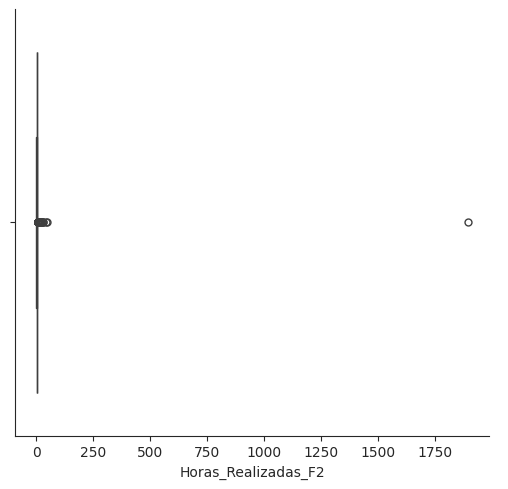

In [ ]:
#Posibles outliers horas realizadas
with sns.axes_style(style='ticks'):
  ax = sns.catplot(data=df_informe062024, x="Horas_Realizadas_F2",  kind="box")

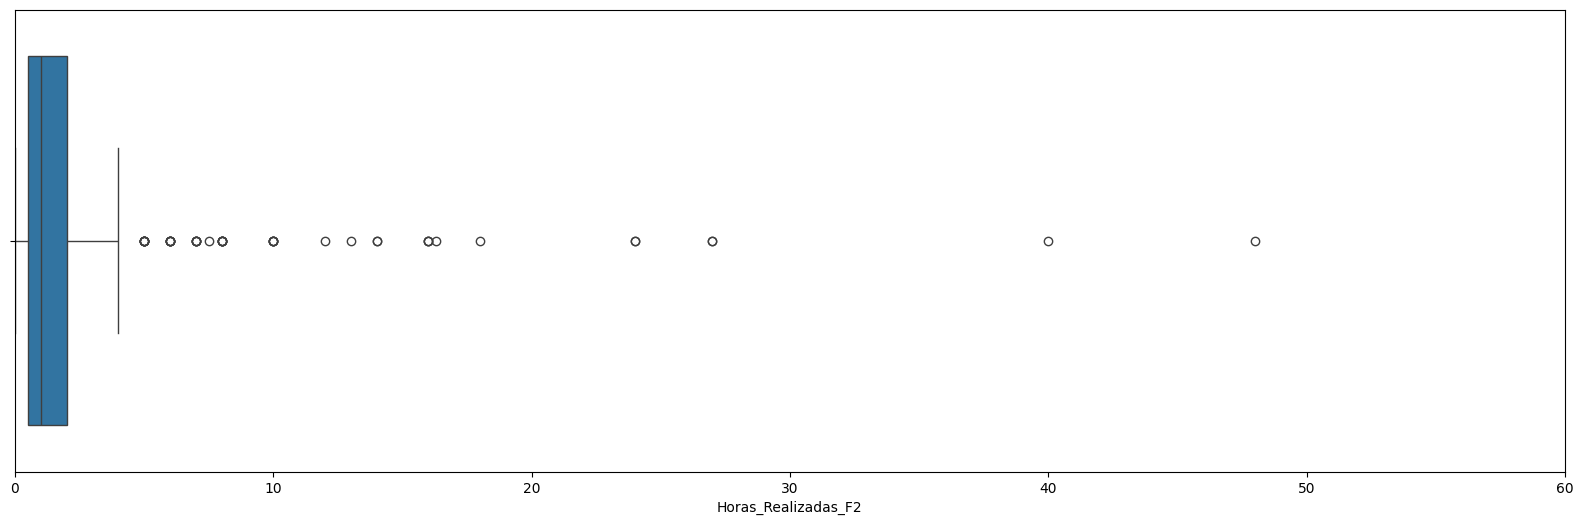

In [ ]:

plt.figure(figsize=[20,6])
sns.boxplot(data=df_informe062024, x="Horas_Realizadas_F2")
plt.xlim(0,60)
plt.show()